In [26]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader,random_split
import sys
import os

sys.path.append(os.path.abspath('..'))

from myLibrary import plot_losses,show_vae_reconstructions, show_vae_samples



# MNIST images are 28x28, single channel, pixel values in [0, 255]
# We convert to tensor (scales to [0, 1]) 
transform = transforms.Compose([
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    transforms.ToTensor(),
])

full_train = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

batch_size = 128

val_size = 5000
train_size = len(full_train) - val_size

train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2  # set to 0 if you hit multiprocessing issues on Mac
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

# sanity check
images, labels = next(iter(train_loader))
print(images.shape)  # should be [128, 1, 28, 28]
print(images.min(), images.max())  # should be ~0.0, ~1.0

ImportError: cannot import name 'show_vae_reconstructions' from 'myLibrary' (/Users/ulasuregen/repos/deepLearningLab/myLibrary.py)

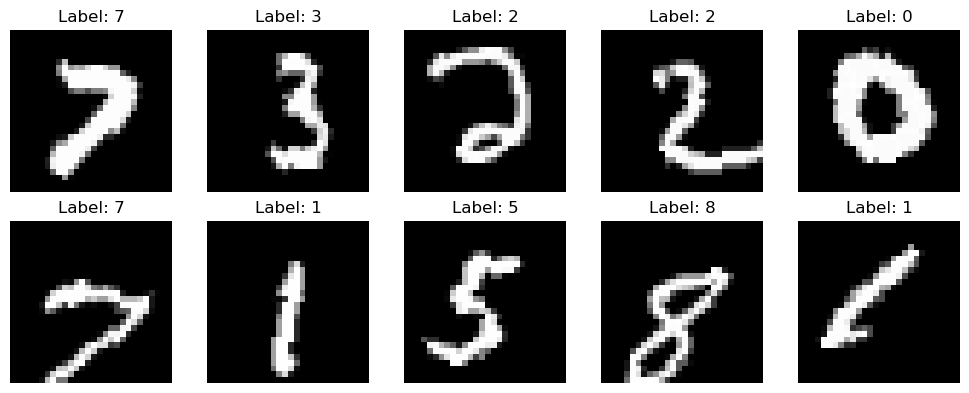

In [22]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Encoder Part:

In [4]:
import torch.nn as nn

class Encoder(nn.Module):

    def __init__(self, laten_dim = 20):
        super().__init__()

        self.module = nn.Sequential(
            nn.Conv2d(in_channels= 1, out_channels= 32, kernel_size= 3, stride= 2, padding= 1), # 1x28x28 -> 32x14x14
            nn.ReLU(),
            nn.Conv2d(in_channels= 32, out_channels= 64, kernel_size= 3, stride= 2, padding= 1), # 32x14x14 -> 64x7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(in_features= 3136, out_features= 1568),
            nn.ReLU(),
            nn.Linear(in_features= 1568, out_features= laten_dim*2)
        )
    
    def forward(self, x):

        x = self.module(x)
        mu, logvar = torch.chunk(x, 2, dim = 1)

        return mu, logvar # mu, logvar


#### Sanity Check

In [6]:
encoder = Encoder(laten_dim=20)
x = torch.randn(8, 1, 28, 28)  # fake batch of 8
mu, logvar = encoder(x)
print(mu.shape, logvar.shape)  # should both be [8, 20]

torch.Size([8, 20]) torch.Size([8, 20])


# Decoder Part: 

In [8]:
class Decoder(nn.Module):

    def __init__(self, laten_dim = 20):
        super().__init__()

        self.module = nn.Sequential(
            nn.Linear(in_features= laten_dim, out_features=1568),
            nn.ReLU(),
            nn.Linear(in_features= 1568, out_features=3136),
            nn.Unflatten(dim = 1, unflattened_size= (64, 7,7)),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels= 64, out_channels= 32, kernel_size= 3, stride = 2, padding= 1, output_padding= 1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels= 32, out_channels= 1, kernel_size= 3, stride = 2, padding= 1, output_padding= 1),
            nn.Sigmoid()
        )

        # (stride - 1)(spatial - 1) + sptial + kernel - 1
        # = (stride - 1) * (spatial) + kernel
        # -> (stride - 1) * 7 + 3 = 14
    
    def forward(self, x):
        
        x = self.module(x)
        return x


#### Sanity Check

In [9]:
decoder = Decoder(laten_dim=20)
z = torch.randn(8, 20)
out = decoder(z)
print(out.shape)  # should be [8, 1, 28, 28]

torch.Size([8, 1, 28, 28])


# Construction Of VAE

In [10]:
class VAE(nn.Module):

    def __init__(self, laten_dim = 20):
        super().__init__()

        self.Encoder = Encoder(laten_dim= laten_dim)
        self.Decoder = Decoder(laten_dim= laten_dim)


    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def forward(self, x):

        mu, logvar = self.Encoder(x)
         
        z = self.reparameterize(mu, logvar)

        x_hat = self.Decoder(z)

        return x_hat, mu, logvar


In [11]:
import torch.nn.functional as F

def vae_loss(x_hat, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

-----------

# Traning Phase

In [14]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

laten_dim = 20
model = VAE(laten_dim=laten_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20

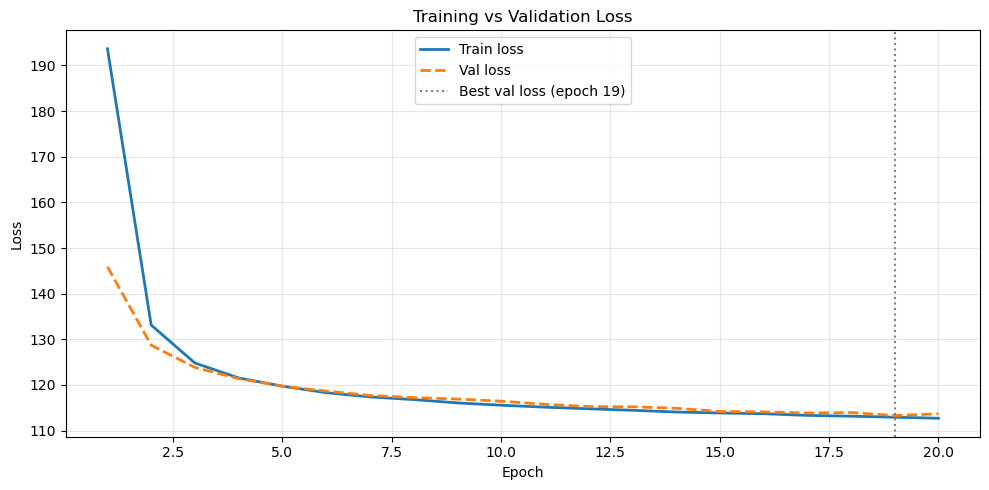

In [24]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    val_loss = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()
        
        x_hat,mu, logvar = model(x)
        loss = vae_loss(x_hat, x, mu, logvar)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader.dataset)

    model.eval()

    with torch.no_grad():

        for x, _ in val_loader:
            x = x.to(device)

            x_hat, mu, logvar = model(x)
            loss = vae_loss(x_hat, x, mu, logvar)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader.dataset)

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    plot_losses(train_losses, val_losses)  # updates in place each epoch



In [ ]:
show_vae_reconstructions(model, val_loader, device)
show_vae_samples(model, laten_dim, device)